# Bangla Audio Deepfake Detection
## WavLM-Large + Modified AASIST + OC-Softmax + RawBoost

This notebook now supports Kaggle-style dataset input from a zipped `Data` folder and runs a hybrid ablation + full-data experiment suite.

Experiments executed:
1. Hold out `crikk_deepfake` for test
2. Hold out `lstm_deepfake` for test
3. Hold out `gemini_deepfake` for test
4. Hold out `baglafake_deepfake` for test
5. Full-dataset stratified split (`train/val/test`)

For holdout experiments:
- Train uses fake samples from the remaining 3 fake folders
- Test uses fake samples only from the held-out folder
- Real samples are split into train/test using the same ratio as fake train/test
- Validation is split only from the training pool

For the full-dataset stratified experiment:
- Train/validation/test are created via stratified split across `(label, source)`
- Test metrics are reported under `stratified_test_*` fields/files

All models, plots, predictions, manifests, and summaries are saved under the experiment output directory.

---

In [1]:
import os, re, glob, random, warnings, json, math
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from scipy.signal import fftconvolve, butter, sosfilt
from scipy.stats import norm as scipy_norm
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import WavLMModel

warnings.filterwarnings('ignore')
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# ======================== Configuration ========================

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
IS_KAGGLE = os.path.exists('/kaggle/input')
OUTPUT_ROOT = '/kaggle/working/wavlm_aasist_outputs' if IS_KAGGLE else './wavlm_aasist_outputs'
os.makedirs(OUTPUT_ROOT, exist_ok=True)

REAL_FOLDERS = ['banglafake_real', 'lstm_real']
FAKE_FOLDERS = ['baglafake_deepfake', 'crikk_deepfake', 'gemini_deepfake', 'lstm_deepfake']
ALL_REQUIRED_FOLDERS = REAL_FOLDERS + FAKE_FOLDERS

def _norm_name(name):
    return re.sub(r'[^a-z0-9]', '', name.lower())

def _resolve_folder_aliases(root_dir, expected_names):
    """Map expected folder names to actual directories with tolerant matching."""
    if not os.path.isdir(root_dir):
        return None

    children = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    children_norm = {_norm_name(d): d for d in children}

    aliases = {
        'baglafake_deepfake': ['baglafake_deepfake', 'banglafake_deepfake'],
        'banglafake_real': ['banglafake_real', 'baglafake_real'],
        'crikk_deepfake': ['crikk_deepfake'],
        'gemini_deepfake': ['gemini_deepfake'],
        'lstm_deepfake': ['lstm_deepfake'],
        'lstm_real': ['lstm_real'],
    }

    resolved = {}
    for exp in expected_names:
        candidates = aliases.get(exp, [exp])
        found = None
        for c in candidates:
            c_norm = _norm_name(c)
            if c_norm in children_norm:
                found = os.path.join(root_dir, children_norm[c_norm])
                break
        if found is None:
            return None
        resolved[exp] = found

    return resolved

def resolve_data_root(required_folders):
    """Resolve Data root locally or on Kaggle, including nested dataset folder layouts."""
    candidates = [
        './Data',
        './Bangla Audio DeepFake/Data',
        '/kaggle/working/Data',
        '/kaggle/input/Data',
    ]

    for c in candidates:
        mapped = _resolve_folder_aliases(c, required_folders)
        if mapped is not None:
            return os.path.abspath(c), mapped

    if os.path.isdir('/kaggle/input'):
        dataset_roots = sorted(glob.glob('/kaggle/input/*'))
        for ds in dataset_roots:
            mapped = _resolve_folder_aliases(ds, required_folders)
            if mapped is not None:
                return os.path.abspath(ds), mapped

            for root, dirs, _ in os.walk(ds):
                rel = os.path.relpath(root, ds)
                depth = 0 if rel == '.' else rel.count(os.sep) + 1
                if depth > 3:
                    dirs[:] = []
                    continue

                if os.path.basename(root).lower() == 'data':
                    mapped = _resolve_folder_aliases(root, required_folders)
                    if mapped is not None:
                        return os.path.abspath(root), mapped

    raise FileNotFoundError(
        'Could not locate Data folder with required subfolders. '
        'Please verify your Kaggle dataset extraction path and folder names.'
    )

DATA_ROOT, RESOLVED_DATA_FOLDERS = resolve_data_root(ALL_REQUIRED_FOLDERS)
print(f'Data root: {DATA_ROOT}')
print(f'Output root: {os.path.abspath(OUTPUT_ROOT)}')

# Experiments: 4 leave-one-fake-out ablations + 1 full stratified special run
ALL_EXPERIMENTS = [
    {'name': 'holdout_crikk', 'holdout_fake': 'crikk_deepfake', 'split_type': 'holdout'},
    {'name': 'holdout_lstm', 'holdout_fake': 'lstm_deepfake', 'split_type': 'holdout'},
    {'name': 'holdout_gemini', 'holdout_fake': 'gemini_deepfake', 'split_type': 'holdout'},
    {'name': 'holdout_baglafake', 'holdout_fake': 'baglafake_deepfake', 'split_type': 'holdout'},
    {'name': 'full_dataset_stratified', 'split_type': 'stratified_full'},
]

# Toggle 1: 'all' or 'one'
RUN_EXPERIMENT_MODE = 'all'

# Toggle 2: used only when RUN_EXPERIMENT_MODE == 'one'
SINGLE_EXPERIMENT_NAME = 'holdout_crikk'

valid_names = [e['name'] for e in ALL_EXPERIMENTS]
if RUN_EXPERIMENT_MODE not in ['all', 'one']:
    raise ValueError("RUN_EXPERIMENT_MODE must be 'all' or 'one'")

if RUN_EXPERIMENT_MODE == 'all':
    EXPERIMENTS = ALL_EXPERIMENTS
else:
    if SINGLE_EXPERIMENT_NAME not in valid_names:
        raise ValueError(
            f"Invalid SINGLE_EXPERIMENT_NAME: {SINGLE_EXPERIMENT_NAME}. "
            f"Choose from: {valid_names}"
        )
    EXPERIMENTS = [e for e in ALL_EXPERIMENTS if e['name'] == SINGLE_EXPERIMENT_NAME]

# Audio
SAMPLE_RATE = 16000
AUDIO_DURATION = 5
MAX_AUDIO_LEN = SAMPLE_RATE * AUDIO_DURATION

# Model
WAVLM_MODEL_NAME = 'microsoft/wavlm-large'
WAVLM_DIM = 1024
WAVLM_FREEZE_LAYERS = 12
AASIST_HIDDEN = 160
AASIST_EMB_DIM = 128
AASIST_NUM_HEADS = 4
AASIST_NUM_GAT_LAYERS = 2
NUM_SPECTRAL_NODES = 32
DROPOUT = 0.3

# OC-Softmax
OC_MARGIN = 0.5
OC_SCALE = 10.0

# Training
BATCH_SIZE = 4
ACCUMULATION_STEPS = 4
NUM_EPOCHS = 20
LR_WAVLM = 1e-5
LR_AASIST = 1e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
PATIENCE = 7
NUM_WORKERS = 0

# Split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f'Device: {DEVICE}')
print(f'Effective batch size: {BATCH_SIZE * ACCUMULATION_STEPS}')
print(f'Run mode: {RUN_EXPERIMENT_MODE}')
print(f'Experiments to run: {[e["name"] for e in EXPERIMENTS]}')

Data root: /kaggle/input/datasets/prithuanan/bangla-audio-deepfake/Data
Output root: /kaggle/working/wavlm_aasist_outputs
Device: cuda
Effective batch size: 16
Run mode: all
Experiments to run: ['holdout_crikk', 'holdout_lstm', 'holdout_gemini', 'holdout_baglafake', 'full_dataset_stratified']


---
## Step 2 — Data Pipeline

Load audio paths from the new `Data` folder, prepare source labels, and build stratified splits for experiment runs.

In [3]:
def extract_speaker_id(filepath, source):
    """Best-effort speaker identity extraction from filename and source folder."""
    fname = os.path.splitext(os.path.basename(filepath))[0]
    parts = re.split(r'[_\-]', fname)

    if len(parts) >= 2:
        spk = f'{parts[0]}_{parts[1]}'
    elif len(parts) == 1:
        spk = parts[0]
    else:
        spk = 'unk'

    return f'{source}_{spk}'


def collect_audio_files(folder_path):
    """Collect audio files recursively with case-insensitive extension handling."""
    if not os.path.isdir(folder_path):
        return []

    exts = {'.wav', '.flac', '.mp3', '.m4a', '.ogg'}
    files = []
    for root, _, fnames in os.walk(folder_path):
        for fn in fnames:
            if os.path.splitext(fn)[1].lower() in exts:
                files.append(os.path.join(root, fn))

    return sorted(files)


def build_dataset_df(data_root, exclude_fake=None):
    records = []

    use_fake_folders = [f for f in FAKE_FOLDERS if f != exclude_fake]

    for folder in REAL_FOLDERS:
        folder_path = RESOLVED_DATA_FOLDERS[folder]
        audio_files = collect_audio_files(folder_path)
        for fp in audio_files:
            records.append({
                'filepath': fp,
                'label': 0,
                'label_name': 'Real',
                'source': folder,
                'speaker_id': extract_speaker_id(fp, folder),
            })

    for folder in use_fake_folders:
        folder_path = RESOLVED_DATA_FOLDERS[folder]
        audio_files = collect_audio_files(folder_path)
        for fp in audio_files:
            records.append({
                'filepath': fp,
                'label': 1,
                'label_name': 'Fake',
                'source': folder,
                'speaker_id': extract_speaker_id(fp, folder),
            })

    if len(records) == 0:
        raise RuntimeError(f'No audio files found under resolved paths from {data_root}')

    return pd.DataFrame(records)


df = build_dataset_df(DATA_ROOT, exclude_fake=None)
print(f'Total samples: {len(df)}')
print(f"\nClass distribution:\n{df['label_name'].value_counts()}")
print('\nSamples per source:')
print(df.groupby(['source', 'label_name']).size().unstack(fill_value=0))
print(f"\nUnique speaker IDs (estimated): {df['speaker_id'].nunique()}")

Total samples: 7311

Class distribution:
label_name
Fake    3911
Real    3400
Name: count, dtype: int64

Samples per source:
label_name          Fake  Real
source                        
baglafake_deepfake  1000     0
banglafake_real        0  2400
crikk_deepfake      1000     0
gemini_deepfake      911     0
lstm_deepfake       1000     0
lstm_real              0  1000

Unique speaker IDs (estimated): 3912


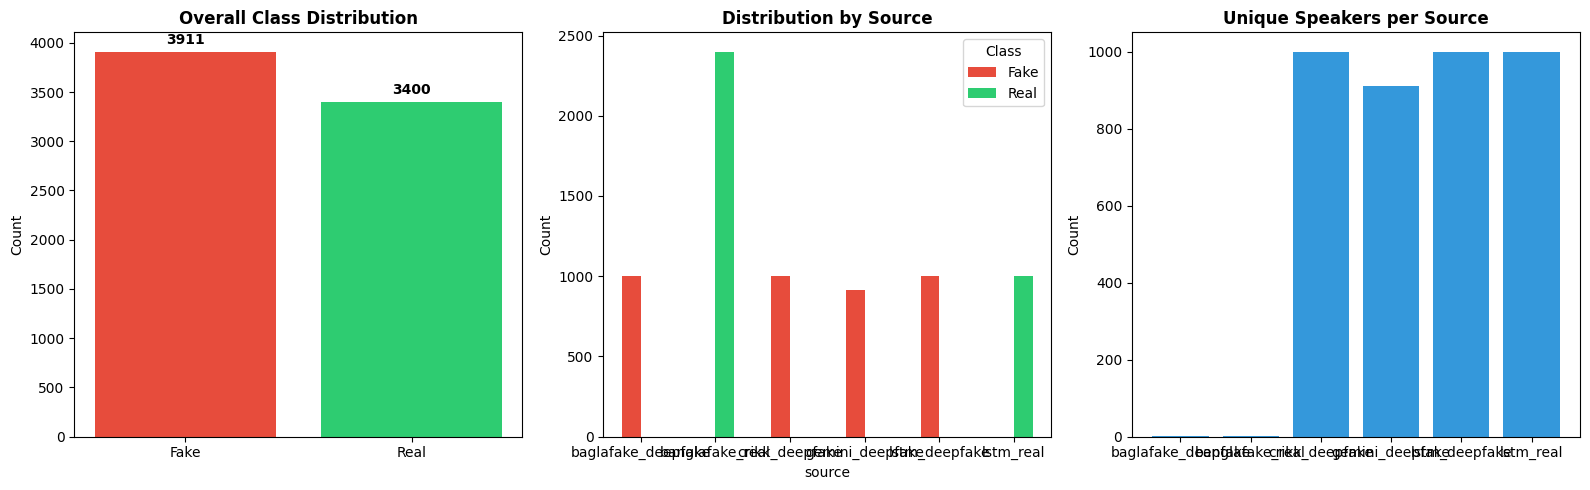

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df['label_name'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Overall Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 80,
                 str(int(b.get_height())), ha='center', fontweight='bold')

src_counts = df.groupby(['source', 'label_name']).size().unstack(fill_value=0)
src_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Distribution by Source', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Class')

speaker_counts = df.groupby('source')['speaker_id'].nunique()
axes[2].bar(speaker_counts.index, speaker_counts.values, color='#3498db')
axes[2].set_title('Unique Speakers per Source', fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def stratified_split(df, train_ratio=0.70, val_ratio=0.15, seed=42):
    """Stratified split by combined (label, source) strata."""
    rng = np.random.default_rng(seed)
    train_parts, val_parts, test_parts = [], [], []

    df = df.copy()
    df['stratum'] = df['label'].astype(str) + '__' + df['source'].astype(str)
    out_columns = df.columns.tolist()

    for _, part in df.groupby('stratum'):
        idx = part.index.to_numpy()
        rng.shuffle(idx)

        n = len(idx)
        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        n_train = min(n_train, n)
        n_val = min(n_val, max(0, n - n_train))

        train_idx = idx[:n_train]
        val_idx = idx[n_train:n_train + n_val]
        test_idx = idx[n_train + n_val:]

        if len(train_idx) > 0:
            train_parts.append(df.loc[train_idx])
        if len(val_idx) > 0:
            val_parts.append(df.loc[val_idx])
        if len(test_idx) > 0:
            test_parts.append(df.loc[test_idx])

    def _concat_or_empty(parts):
        if len(parts) == 0:
            return pd.DataFrame(columns=out_columns)
        return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

    train_df = _concat_or_empty(train_parts)
    val_df = _concat_or_empty(val_parts)
    test_df = _concat_or_empty(test_parts)

    for out_df in (train_df, val_df, test_df):
        if 'stratum' in out_df.columns:
            out_df.drop(columns=['stratum'], inplace=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = stratified_split(df, TRAIN_RATIO, VAL_RATIO, SEED)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    nr = (split['label'] == 0).sum()
    nf = (split['label'] == 1).sum()
    print(f"{name:5s}: {len(split):6d} samples | {nr:5d} real, {nf:5d} fake")

print('\nPer-source composition by split:')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'\n{name}:')
    print(split.groupby(['source', 'label_name']).size().unstack(fill_value=0))

Train:   5118 samples |  2380 real,  2738 fake
Val  :   1097 samples |   510 real,   587 fake
Test :   1096 samples |   510 real,   586 fake

Per-source composition by split:

Train:
label_name          Fake  Real
source                        
baglafake_deepfake   700     0
banglafake_real        0  1680
crikk_deepfake       700     0
gemini_deepfake      638     0
lstm_deepfake        700     0
lstm_real              0   700

Val:
label_name          Fake  Real
source                        
baglafake_deepfake   150     0
banglafake_real        0   360
crikk_deepfake       150     0
gemini_deepfake      137     0
lstm_deepfake        150     0
lstm_real              0   150

Test:
label_name          Fake  Real
source                        
baglafake_deepfake   150     0
banglafake_real        0   360
crikk_deepfake       150     0
gemini_deepfake      136     0
lstm_deepfake        150     0
lstm_real              0   150


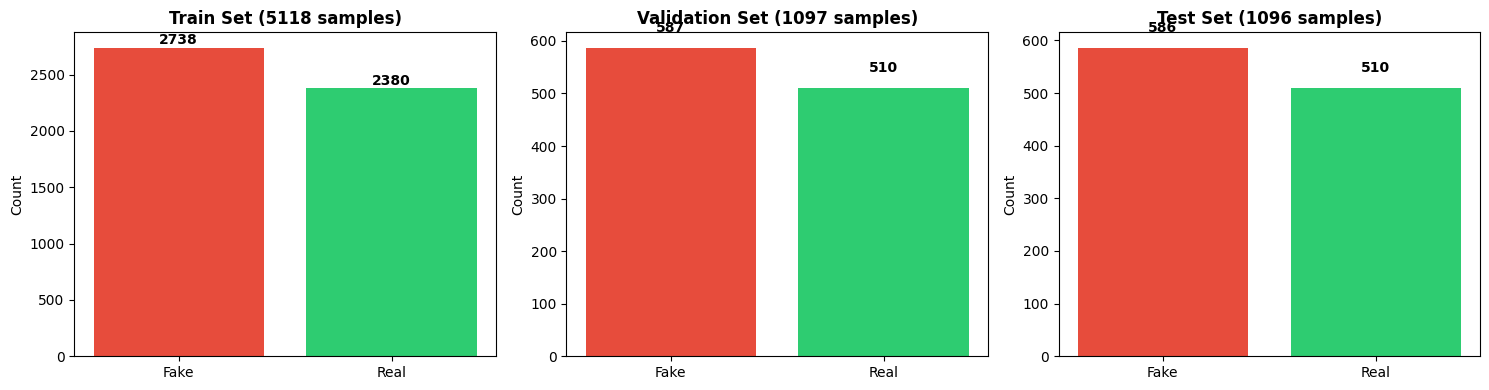

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split_df, name) in zip(axes, [(train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test')]):
    vc = split_df['label_name'].value_counts()
    bars = ax.bar(vc.index, vc.values, color=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{name} Set ({len(split_df)} samples)', fontweight='bold')
    ax.set_ylabel('Count')
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 30,
                str(int(b.get_height())), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2b — RawBoost Data Augmentation

Implements seven augmentation types applied randomly during training:
1. Random gain scaling
2. Additive Gaussian noise (SNR 5-30 dB)
3. Random clipping
4. Reverberation (synthetic RIR convolution)
5. MP3 compression simulation
6. Pitch shift (+-1 semitone)
7. Time stretch (0.9-1.1)

In [7]:
class RawBoost:
    def __init__(self, sr=16000, p=0.6):
        self.sr = sr
        self.p = p

    def __call__(self, audio):
        aug_fns = [
            self.gain_scaling,
            self.additive_noise,
            self.random_clipping,
            self.reverberation,
            self.mp3_compression_sim,
            self.pitch_shift,
            self.time_stretch,
        ]
        n_augs = random.randint(1, 3)
        chosen = random.sample(aug_fns, min(n_augs, len(aug_fns)))
        for fn in chosen:
            if random.random() < self.p:
                audio = fn(audio)
        return np.clip(audio, -1.0, 1.0).astype(np.float32)

    def gain_scaling(self, audio):
        gain = 10 ** (random.uniform(-6, 6) / 20)
        return audio * gain

    def additive_noise(self, audio):
        snr_db = random.uniform(5, 30)
        sig_power = np.mean(audio ** 2) + 1e-10
        noise_power = sig_power / (10 ** (snr_db / 10))
        return audio + np.random.randn(len(audio)).astype(np.float32) * np.sqrt(noise_power)

    def random_clipping(self, audio):
        thresh = np.max(np.abs(audio)) * random.uniform(0.5, 0.9)
        return np.clip(audio, -thresh, thresh)

    def reverberation(self, audio):
        rt60 = random.uniform(0.2, 0.8)
        n = int(self.sr * rt60)
        t = np.arange(n, dtype=np.float32) / self.sr
        rir = np.random.randn(n).astype(np.float32) * np.exp(-6.9 * t / rt60)
        rir[0] = 1.0
        rir /= np.abs(rir).max() + 1e-8
        rev = fftconvolve(audio, rir, mode='full')[:len(audio)].astype(np.float32)
        mix = random.uniform(0.3, 0.7)
        return (1 - mix) * audio + mix * rev

    def mp3_compression_sim(self, audio):
        cutoff = random.uniform(4000, 8000)
        sos = butter(5, cutoff / (self.sr / 2), btype='low', output='sos')
        filtered = sosfilt(sos, audio).astype(np.float32)
        bits = random.choice([8, 10, 12])
        scale = 2 ** (bits - 1)
        return np.round(filtered * scale).astype(np.float32) / scale

    def pitch_shift(self, audio):
        n_steps = random.uniform(-1, 1)
        return librosa.effects.pitch_shift(audio, sr=self.sr, n_steps=n_steps)

    def time_stretch(self, audio):
        rate = random.uniform(0.9, 1.1)
        stretched = librosa.effects.time_stretch(audio, rate=rate)
        if len(stretched) >= len(audio):
            return stretched[:len(audio)]
        return np.pad(stretched, (0, len(audio) - len(stretched)))

print("RawBoost augmentation ready.")

RawBoost augmentation ready.


---
## Step 3 — Audio Dataset & DataLoaders

On-the-fly audio loading with optional RawBoost augmentation.
Audio is loaded at 16 kHz, padded/truncated to 5 seconds, and normalized.

In [8]:
class BanglaAudioDataset(Dataset):
    def __init__(self, dataframe, sr=SAMPLE_RATE, duration=AUDIO_DURATION, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.sr = sr
        self.max_len = sr * duration
        self.augment = augment
        self.rawboost = RawBoost(sr=sr) if augment else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio, _ = librosa.load(row['filepath'], sr=self.sr, duration=self.max_len / self.sr)

        if len(audio) < self.max_len:
            audio = np.pad(audio, (0, self.max_len - len(audio)))
        else:
            audio = audio[:self.max_len]

        if self.augment and self.rawboost is not None:
            audio = self.rawboost(audio)

        audio = (audio - audio.mean()) / (audio.std() + 1e-7)
        return torch.from_numpy(audio.astype(np.float32)), torch.tensor(row['label'], dtype=torch.long)


train_ds = BanglaAudioDataset(train_df, augment=True)
val_ds   = BanglaAudioDataset(val_df,   augment=False)
test_ds  = BanglaAudioDataset(test_df,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")

Train: 5118 samples, 1279 batches
Val:   1097 samples, 275 batches
Test:  1096 samples, 274 batches


---
## Step 3-5 — Model Architecture

### WavLM Frontend
- Pretrained `microsoft/wavlm-large` (24 transformer layers, 1024-dim)
- Freeze feature extractor + first 12 transformer layers
- Fine-tune remaining 12 layers

### Modified AASIST Backend (without SincNet)
- Temporal convolutions for local pattern extraction
- Learnable spectral nodes via soft attention over temporal features
- Heterogeneous graph attention (temporal + spectral nodes)
- Attention-based readout -> 128-dim embedding

### OC-Softmax Loss
- Learnable class center for bonafide (real) speech
- Cosine similarity scoring with angular margin
- Real pushed above margin, fake pushed below

In [9]:
class ModifiedAASIST(nn.Module):
    """Modified AASIST backend: graph attention over WavLM features."""

    def __init__(self, input_dim=1024, hidden_dim=160, emb_dim=128,
                 num_heads=4, num_gat_layers=2, num_spectral_nodes=32,
                 max_seq_len=512, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )
        self.pos_enc = nn.Parameter(torch.randn(1, max_seq_len, hidden_dim) * 0.02)

        # Temporal branch
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1, groups=hidden_dim),
            nn.Conv1d(hidden_dim, hidden_dim, 1),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
        )

        # Spectral node creation
        self.num_spectral_nodes = num_spectral_nodes
        self.spectral_basis = nn.Parameter(torch.randn(num_spectral_nodes, hidden_dim) * 0.02)
        self.spectral_proj = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim))

        # Graph attention layers
        self.gat_layers = nn.ModuleList()
        self.gat_norms1 = nn.ModuleList()
        self.gat_ffn = nn.ModuleList()
        self.gat_norms2 = nn.ModuleList()
        for _ in range(num_gat_layers):
            self.gat_layers.append(
                nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True))
            self.gat_norms1.append(nn.LayerNorm(hidden_dim))
            self.gat_ffn.append(nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 4), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(hidden_dim * 4, hidden_dim), nn.Dropout(dropout),
            ))
            self.gat_norms2.append(nn.LayerNorm(hidden_dim))

        # Readout
        self.readout_query = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        self.readout_attn = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.readout_norm = nn.LayerNorm(hidden_dim)

        # Output
        self.output_fc = nn.Sequential(
            nn.Linear(hidden_dim, emb_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(emb_dim, emb_dim),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, _ = x.shape
        h = self.input_proj(x) + self.pos_enc[:, :T, :]
        h = self.drop(h)

        # Temporal conv
        h = h + self.temporal_conv(h.transpose(1, 2)).transpose(1, 2)

        # Create spectral nodes
        S = self.spectral_basis.unsqueeze(0).expand(B, -1, -1)
        w = F.softmax(torch.bmm(S, h.transpose(1, 2)) / math.sqrt(h.size(-1)), dim=-1)
        spectral = self.spectral_proj(torch.bmm(w, h))

        nodes = torch.cat([h, spectral], dim=1)

        # GAT layers
        for gat, n1, ffn, n2 in zip(self.gat_layers, self.gat_norms1, self.gat_ffn, self.gat_norms2):
            res = nodes
            out, _ = gat(n1(nodes), n1(nodes), n1(nodes))
            nodes = res + self.drop(out)
            nodes = nodes + ffn(n2(nodes))

        # Attention readout
        q = self.readout_query.expand(B, -1, -1)
        out, attn_weights = self.readout_attn(q, nodes, nodes)
        readout = self.readout_norm(out).squeeze(1)

        return self.output_fc(readout), attn_weights

_test = ModifiedAASIST(input_dim=WAVLM_DIM, hidden_dim=AASIST_HIDDEN, emb_dim=AASIST_EMB_DIM,
                       num_heads=AASIST_NUM_HEADS, num_gat_layers=AASIST_NUM_GAT_LAYERS,
                       num_spectral_nodes=NUM_SPECTRAL_NODES, dropout=DROPOUT)
_dummy = torch.randn(2, 250, WAVLM_DIM)
_emb, _attn = _test(_dummy)
print(f"AASIST test -- input: {_dummy.shape} -> embedding: {_emb.shape}, attn: {_attn.shape}")
del _test, _dummy, _emb, _attn

AASIST test -- input: torch.Size([2, 250, 1024]) -> embedding: torch.Size([2, 128]), attn: torch.Size([2, 1, 282])


In [10]:
class OCSoftmaxLoss(nn.Module):
    """One-Class Softmax loss for anti-spoofing."""

    def __init__(self, feat_dim=128, margin=0.5, scale=10.0):
        super().__init__()
        self.w = nn.Parameter(torch.empty(feat_dim))
        nn.init.normal_(self.w, mean=0, std=0.01)
        self.margin = margin
        self.scale = scale

    def score(self, x):
        return F.cosine_similarity(
            F.normalize(x, dim=1),
            F.normalize(self.w.unsqueeze(0), dim=1).expand_as(x),
            dim=1)

    def forward(self, x, labels):
        cos_theta = self.score(x)
        is_real = (labels == 0).float()
        is_fake = (labels == 1).float()

        logits = (is_real * self.scale * (cos_theta - self.margin)
                  + is_fake * self.scale * (self.margin - cos_theta))

        loss = F.binary_cross_entropy_with_logits(logits, torch.ones_like(logits))
        return loss, cos_theta

print("OC-Softmax loss ready.")

OC-Softmax loss ready.


In [11]:
class BanglaDeepfakeDetector(nn.Module):
    """Complete model: WavLM frontend + Modified AASIST + OC-Softmax."""

    def __init__(self):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained(WAVLM_MODEL_NAME)
        self._freeze_wavlm()

        self.aasist = ModifiedAASIST(
            input_dim=WAVLM_DIM, hidden_dim=AASIST_HIDDEN, emb_dim=AASIST_EMB_DIM,
            num_heads=AASIST_NUM_HEADS, num_gat_layers=AASIST_NUM_GAT_LAYERS,
            num_spectral_nodes=NUM_SPECTRAL_NODES, dropout=DROPOUT,
        )
        self.oc_softmax = OCSoftmaxLoss(
            feat_dim=AASIST_EMB_DIM, margin=OC_MARGIN, scale=OC_SCALE,
        )

    def _freeze_wavlm(self):
        self.wavlm.feature_extractor._freeze_parameters()
        for p in self.wavlm.feature_projection.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.wavlm.encoder.layers):
            if i < WAVLM_FREEZE_LAYERS:
                for p in layer.parameters():
                    p.requires_grad = False

    def forward(self, audio, labels=None):
        feats = self.wavlm(input_values=audio).last_hidden_state
        emb, attn = self.aasist(feats)

        if labels is not None:
            loss, scores = self.oc_softmax(emb, labels)
            return loss, scores, emb, attn

        return self.oc_softmax.score(emb), emb, attn

    def wavlm_params(self):
        return [p for p in self.wavlm.parameters() if p.requires_grad]

    def backend_params(self):
        return list(self.aasist.parameters()) + list(self.oc_softmax.parameters())

model = BanglaDeepfakeDetector().to(DEVICE)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {n_total:,}")
print(f"Trainable parameters: {n_train:,}")
print(f"Frozen parameters:    {n_total - n_train:,}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Total parameters:     316,516,608
Trainable parameters: 160,617,440
Frozen parameters:    155,899,168


---
## Step 6 — Training

- **Optimizer:** AdamW with differential learning rates (1e-5 WavLM, 1e-4 AASIST)
- **Scheduler:** Cosine annealing
- **Mixed precision** training with gradient accumulation
- **Early stopping** on validation EER (patience=7)
- **Gradient clipping** at 1.0

In [12]:
def compute_eer(y_true, y_scores):
    """EER: y_true 0=real,1=fake; y_scores higher=more real."""
    y_real = 1 - np.asarray(y_true, dtype=int)
    y_scores = np.asarray(y_scores, dtype=np.float64)

    desc = np.argsort(-y_scores)
    y_sorted = y_real[desc]
    scores_sorted = y_scores[desc]

    tps = np.cumsum(y_sorted)
    fps = np.arange(1, len(y_sorted) + 1) - tps

    P = y_sorted.sum()
    N = len(y_sorted) - P
    tpr = tps / max(P, 1)
    fpr = fps / max(N, 1)
    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = float((fpr[idx] + fnr[idx]) / 2)
    return eer, float(scores_sorted[idx])


def compute_roc_auc(y_true, y_scores):
    """ROC curve and AUC."""
    y_real = 1 - np.asarray(y_true, dtype=int)
    y_scores = np.asarray(y_scores, dtype=np.float64)

    desc = np.argsort(-y_scores, kind='mergesort')
    y_sorted = y_real[desc]
    scores_sorted = y_scores[desc]

    distinct = np.where(np.diff(scores_sorted))[0]
    thresh_idx = np.r_[distinct, len(y_sorted) - 1]

    tps = np.r_[0, np.cumsum(y_sorted)[thresh_idx]]
    fps = np.r_[0, (1 + thresh_idx) - np.cumsum(y_sorted)[thresh_idx]]

    P = y_sorted.sum()
    N = len(y_sorted) - P
    tpr = tps / max(P, 1)
    fpr = fps / max(N, 1)

    auc = float(np.trapz(tpr, fpr))
    return fpr, tpr, auc

print("Metric utilities ready.")

Metric utilities ready.


In [13]:
def train_one_epoch(model, loader, optimizer, scaler, device, grad_clip=1.0, accum_steps=1):
    model.train()
    total_loss, n_samples = 0.0, 0
    all_scores, all_labels = [], []

    optimizer.zero_grad()
    pbar = tqdm(loader, desc="  Train")
    for step, (audio, labels) in enumerate(pbar):
        audio, labels = audio.to(device), labels.to(device)

        with autocast(dtype=torch.float16, enabled=(device.type == 'cuda')):
            loss, scores, _, _ = model(audio, labels)
            loss = loss / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps * len(labels)
        n_samples += len(labels)
        all_scores.extend(scores.detach().cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        pbar.set_postfix(loss=f"{loss.item() * accum_steps:.4f}")

    avg_loss = total_loss / n_samples
    preds = [0 if s > 0 else 1 for s in all_scores]
    acc = sum(p == l for p, l in zip(preds, all_labels)) / len(all_labels)
    eer, _ = compute_eer(all_labels, all_scores)
    return avg_loss, acc, eer


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n_samples = 0.0, 0
    all_scores, all_labels, all_embs = [], [], []

    for audio, labels in tqdm(loader, desc="  Eval "):
        audio, labels = audio.to(device), labels.to(device)
        with autocast(dtype=torch.float16, enabled=(device.type == 'cuda')):
            loss, scores, emb, _ = model(audio, labels)

        total_loss += loss.item() * len(labels)
        n_samples += len(labels)
        all_scores.extend(scores.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_embs.append(emb.cpu().numpy())

    avg_loss = total_loss / n_samples
    scores_arr = np.array(all_scores)
    labels_arr = np.array(all_labels)
    preds_arr = np.array([0 if s > 0 else 1 for s in all_scores])

    acc = float((preds_arr == labels_arr).mean())
    eer, eer_thresh = compute_eer(labels_arr, scores_arr)
    fpr, tpr, auc = compute_roc_auc(labels_arr, scores_arr)

    return {
        'loss': avg_loss, 'acc': acc, 'eer': eer, 'eer_threshold': eer_thresh,
        'auc': auc, 'scores': scores_arr, 'labels': labels_arr, 'preds': preds_arr,
        'embeddings': np.concatenate(all_embs), 'fpr': fpr, 'tpr': tpr,
    }

print("Training utilities ready.")

Training utilities ready.


In [14]:
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def save_split_manifests(train_df, val_df, test_df, out_dir):
    mdir = ensure_dir(os.path.join(out_dir, 'manifests'))
    train_df.to_csv(os.path.join(mdir, 'train_manifest.csv'), index=False)
    val_df.to_csv(os.path.join(mdir, 'val_manifest.csv'), index=False)
    test_df.to_csv(os.path.join(mdir, 'test_manifest.csv'), index=False)

def make_loaders(train_df, val_df, test_df):
    train_ds = BanglaAudioDataset(train_df, augment=True)
    val_ds = BanglaAudioDataset(val_df, augment=False)
    test_ds = BanglaAudioDataset(test_df, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

def split_leave_one_fake_out_df(df_all, holdout_fake, val_ratio=0.15, seed=42):
    """Train on 3 fake sources; test on held-out fake source; split real with matched train:test ratio."""
    fake_df = df_all[df_all['label'] == 1].reset_index(drop=True)
    real_df = df_all[df_all['label'] == 0].reset_index(drop=True)

    fake_test = fake_df[fake_df['source'] == holdout_fake].copy().reset_index(drop=True)
    fake_train = fake_df[fake_df['source'] != holdout_fake].copy().reset_index(drop=True)

    if len(fake_test) == 0 or len(fake_train) == 0:
        raise ValueError(f'Invalid holdout split for {holdout_fake}: empty fake train/test set.')

    fake_train_ratio = len(fake_train) / float(len(fake_train) + len(fake_test))

    real_idx = np.arange(len(real_df))
    rng = np.random.default_rng(seed)
    rng.shuffle(real_idx)

    n_real_train = int(round(len(real_df) * fake_train_ratio))
    n_real_train = max(1, min(len(real_df) - 1, n_real_train))

    real_train = real_df.iloc[real_idx[:n_real_train]].copy().reset_index(drop=True)
    real_test = real_df.iloc[real_idx[n_real_train:]].copy().reset_index(drop=True)

    train_pool = pd.concat([fake_train, real_train], ignore_index=True)
    test_df = pd.concat([fake_test, real_test], ignore_index=True)

    # Validation comes only from training pool
    train_df, val_df, spill_df = stratified_split(train_pool, train_ratio=1.0 - val_ratio, val_ratio=val_ratio, seed=seed)
    if len(spill_df) > 0:
        train_df = pd.concat([train_df, spill_df], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)

    test_df = test_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_df, val_df, test_df

def split_full_dataset_stratified_df(df_all, train_ratio=0.70, val_ratio=0.15, seed=42):
    """Stratified full-dataset split into train/val/test by (label, source)."""
    train_df, val_df, test_df = stratified_split(
        df_all.copy(), train_ratio=train_ratio, val_ratio=val_ratio, seed=seed
    )
    return train_df, val_df, test_df

def plot_training_history_to_file(history, path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    axes[0, 0].plot(epochs, history['val_loss'], 'r-o', ms=3, label='Validation')
    axes[0, 0].set_title('Loss', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs, history['train_acc'], 'b-o', ms=3, label='Train')
    axes[0, 1].plot(epochs, history['val_acc'], 'r-o', ms=3, label='Validation')
    axes[0, 1].set_title('Accuracy', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(epochs, history['train_eer'], 'b-o', ms=3, label='Train')
    axes[1, 0].plot(epochs, history['val_eer'], 'r-o', ms=3, label='Validation')
    axes[1, 0].set_title('Equal Error Rate (EER)', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('EER')
    axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(epochs, history['val_auc'], 'g-o', ms=3, label='Validation AUC')
    axes[1, 1].set_title('ROC-AUC', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def confusion_and_report(y_true, y_pred):
    labels = ['Real', 'Fake']
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t)][int(p)] += 1

    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0).astype(float) - tp
    fn = cm.sum(axis=1).astype(float) - tp
    support = cm.sum(axis=1).astype(float)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) > 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) > 0)
    acc = tp.sum() / max(support.sum(), 1)

    report = {
        'accuracy': float(acc),
        'precision_real': float(precision[0]),
        'recall_real': float(recall[0]),
        'f1_real': float(f1[0]),
        'precision_fake': float(precision[1]),
        'recall_fake': float(recall[1]),
        'f1_fake': float(f1[1]),
    }
    return cm, report

def save_confusion_plot(cm, out_path, title='Confusion Matrix'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    labels = ['Real', 'Fake']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=axes[0], cbar=False,
                annot_kws={'size': 16, 'fontweight': 'bold'})
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{title} -- Counts', fontweight='bold')

    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=axes[1], cbar=True,
                annot_kws={'size': 16, 'fontweight': 'bold'})
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title(f'{title} -- Normalized', fontweight='bold')

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_roc_det_plot(fpr, tpr, eer, auc_val, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc_val:.4f})')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0].plot(eer, 1 - eer, 'ro', ms=10, label=f'EER = {eer:.4f}')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    fnr = 1 - tpr
    fpr_c = np.clip(fpr, 1e-4, 1 - 1e-4)
    fnr_c = np.clip(fnr, 1e-4, 1 - 1e-4)
    fpr_p = scipy_norm.ppf(fpr_c)
    fnr_p = scipy_norm.ppf(fnr_c)
    axes[1].plot(fpr_p, fnr_p, 'b-', lw=2)
    eer_p = scipy_norm.ppf(np.clip(eer, 1e-4, 1 - 1e-4))
    axes[1].plot(eer_p, eer_p, 'ro', ms=10, label=f'EER = {eer:.4f}')

    ticks = [0.001, 0.01, 0.05, 0.1, 0.2, 0.4]
    tp = [scipy_norm.ppf(t) for t in ticks]
    tl = [f'{t*100:.1f}%' for t in ticks]
    axes[1].set_xticks(tp); axes[1].set_xticklabels(tl)
    axes[1].set_yticks(tp); axes[1].set_yticklabels(tl)
    axes[1].set_xlabel('False Alarm Rate')
    axes[1].set_ylabel('Miss Rate')
    axes[1].set_title('DET Curve', fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_score_distribution(scores, labels, eer_threshold, out_path):
    fig, ax = plt.subplots(figsize=(10, 5))
    real_scores = scores[labels == 0]
    fake_scores = scores[labels == 1]
    ax.hist(real_scores, bins=60, alpha=0.6, color='#2ecc71', label='Real', density=True)
    ax.hist(fake_scores, bins=60, alpha=0.6, color='#e74c3c', label='Fake', density=True)
    ax.axvline(x=eer_threshold, color='k', ls='--', lw=2, label=f'EER threshold = {eer_threshold:.3f}')
    ax.set_xlabel('OC-Softmax Score')
    ax.set_ylabel('Density')
    ax.set_title('Score Distribution on Test Set', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def apply_noise_10db(audio):
    sig_p = np.mean(audio ** 2) + 1e-10
    noise_p = sig_p / 10.0
    return audio + np.random.randn(len(audio)).astype(np.float32) * np.sqrt(noise_p)

def apply_mp3(audio):
    sos = butter(5, 4000 / (SAMPLE_RATE / 2), btype='low', output='sos')
    f = sosfilt(sos, audio).astype(np.float32)
    return np.round(f * 128).astype(np.float32) / 128

def apply_reverb(audio):
    n = int(SAMPLE_RATE * 0.5)
    t = np.arange(n, dtype=np.float32) / SAMPLE_RATE
    rir = np.random.randn(n).astype(np.float32) * np.exp(-6.9 * t / 0.5)
    rir[0] = 1.0
    rir /= np.abs(rir).max() + 1e-8
    return fftconvolve(audio, rir, mode='full')[:len(audio)].astype(np.float32)

class CorruptedDataset(Dataset):
    def __init__(self, dataframe, corrupt_fn, sr=SAMPLE_RATE, duration=AUDIO_DURATION):
        self.df = dataframe.reset_index(drop=True)
        self.sr = sr
        self.max_len = sr * duration
        self.corrupt_fn = corrupt_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio, _ = librosa.load(row['filepath'], sr=self.sr, duration=self.max_len / self.sr)
        if len(audio) < self.max_len:
            audio = np.pad(audio, (0, self.max_len - len(audio)))
        else:
            audio = audio[:self.max_len]
        audio = self.corrupt_fn(audio)
        audio = (audio - audio.mean()) / (audio.std() + 1e-7)
        return torch.from_numpy(audio.astype(np.float32)), torch.tensor(row['label'], dtype=torch.long)

def run_single_experiment(exp_cfg):
    exp_name = exp_cfg['name']
    split_type = exp_cfg.get('split_type', 'holdout')
    holdout_fake = exp_cfg.get('holdout_fake', None)

    if split_type == 'holdout':
        print(f"\n{'#' * 78}")
        print(f"Experiment: {exp_name} | split_type=holdout | holdout_fake={holdout_fake}")
        print(f"{'#' * 78}")
    else:
        print(f"\n{'#' * 78}")
        print(f"Experiment: {exp_name} | split_type=stratified_full")
        print(f"{'#' * 78}")

    exp_dir = ensure_dir(os.path.join(OUTPUT_ROOT, exp_name))
    plot_dir = ensure_dir(os.path.join(exp_dir, 'plots'))
    pred_dir = ensure_dir(os.path.join(exp_dir, 'predictions'))
    result_dir = ensure_dir(os.path.join(exp_dir, 'results'))
    model_dir = ensure_dir(os.path.join(exp_dir, 'models'))

    df_exp = build_dataset_df(DATA_ROOT, exclude_fake=None)

    if split_type == 'holdout':
        train_df, val_df, test_df = split_leave_one_fake_out_df(
            df_exp, holdout_fake=holdout_fake, val_ratio=VAL_RATIO, seed=SEED
        )
        test_split_name = 'holdout_test'
    elif split_type == 'stratified_full':
        train_df, val_df, test_df = split_full_dataset_stratified_df(
            df_exp, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, seed=SEED
        )
        holdout_fake = ''
        test_split_name = 'stratified_test'
    else:
        raise ValueError(f'Unknown split_type: {split_type}')

    save_split_manifests(train_df, val_df, test_df, exp_dir)

    print(f"Data sizes -- Train: {len(train_df)}, Val: {len(val_df)}, {test_split_name}: {len(test_df)}")

    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)

    model = BanglaDeepfakeDetector().to(DEVICE)
    optimizer = torch.optim.AdamW([
        {'params': model.wavlm_params(), 'lr': LR_WAVLM, 'weight_decay': WEIGHT_DECAY},
        {'params': model.backend_params(), 'lr': LR_AASIST, 'weight_decay': WEIGHT_DECAY},
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))

    history = defaultdict(list)
    best_val_eer = float('inf')
    patience_counter = 0
    best_ckpt_path = os.path.join(model_dir, 'best_model.pt')

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{NUM_EPOCHS} ({exp_name})")
        train_loss, train_acc, train_eer = train_one_epoch(
            model, train_loader, optimizer, scaler, DEVICE, GRAD_CLIP, ACCUMULATION_STEPS
        )
        val_res = evaluate(model, val_loader, DEVICE)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_eer'].append(train_eer)
        history['val_loss'].append(val_res['loss'])
        history['val_acc'].append(val_res['acc'])
        history['val_eer'].append(val_res['eer'])
        history['val_auc'].append(val_res['auc'])

        print(f"Train -- Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | EER: {train_eer:.4f}")
        print(f"Val   -- Loss: {val_res['loss']:.4f} | Acc: {val_res['acc']:.4f} | EER: {val_res['eer']:.4f} | AUC: {val_res['auc']:.4f}")

        if val_res['eer'] < best_val_eer:
            best_val_eer = val_res['eer']
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': dict(history),
                'val_eer': best_val_eer,
                'val_auc': val_res['auc'],
                'eer_threshold': val_res['eer_threshold'],
            }, best_ckpt_path)
            print(f"Best model updated -- Val EER: {best_val_eer:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    plot_training_history_to_file(history, os.path.join(plot_dir, 'training_history.png'))

    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    eer_threshold = ckpt.get('eer_threshold', 0.0)

    test_results = evaluate(model, test_loader, DEVICE)
    test_preds_eer = (test_results['scores'] <= eer_threshold).astype(int)

    pred_df = test_df.copy().reset_index(drop=True)
    pred_df['score'] = test_results['scores']
    pred_df['pred'] = test_results['preds']
    pred_df['pred_eer_threshold'] = test_preds_eer

    if split_type == 'holdout':
        pred_df.to_csv(os.path.join(pred_dir, 'holdout_test_predictions.csv'), index=False)
    else:
        pred_df.to_csv(os.path.join(pred_dir, 'stratified_test_predictions.csv'), index=False)
    pred_df.to_csv(os.path.join(pred_dir, 'test_predictions.csv'), index=False)

    cm, report = confusion_and_report(test_results['labels'], test_results['preds'])
    save_confusion_plot(cm, os.path.join(plot_dir, 'confusion_matrix.png'), title=f'{exp_name} {test_split_name} Confusion Matrix')
    save_roc_det_plot(test_results['fpr'], test_results['tpr'], test_results['eer'], test_results['auc'],
                      os.path.join(plot_dir, 'roc_det_curves.png'))
    save_score_distribution(test_results['scores'], test_results['labels'], eer_threshold,
                            os.path.join(plot_dir, 'score_distribution.png'))

    corruptions = {
        'Clean': None,
        '10dB Noise': apply_noise_10db,
        'MP3 Compress.': apply_mp3,
        'Reverb (0.5s)': apply_reverb,
    }
    robustness_results = {}
    for name, fn in corruptions.items():
        if fn is None:
            res = test_results
        else:
            ds = CorruptedDataset(test_df, fn)
            dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
            res = evaluate(model, dl, DEVICE)
        robustness_results[name] = {'EER': float(res['eer']), 'AUC': float(res['auc']), 'Acc': float(res['acc'])}

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    names = list(robustness_results.keys())
    for ax, metric in zip(axes, ['EER', 'AUC', 'Acc']):
        vals = [robustness_results[n][metric] for n in names]
        colors = ['#2ecc71'] + ['#e74c3c'] * (len(names) - 1)
        bars = ax.bar(names, vals, color=colors)
        ax.set_title(metric, fontsize=13, fontweight='bold')
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                    f'{b.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, 'robustness_comparison.png'), dpi=150, bbox_inches='tight')
    plt.close(fig)

    n_train_fake = int((train_df['label'] == 1).sum())
    n_test_fake = int((test_df['label'] == 1).sum())
    n_train_real = int((train_df['label'] == 0).sum())
    n_test_real = int((test_df['label'] == 0).sum())

    summary = {
        'experiment': exp_name,
        'split_type': split_type,
        'test_split_name': test_split_name,
        'holdout_fake_source': holdout_fake if split_type == 'holdout' else '',
        'dataset_size': int(len(df_exp)),
        'train_size': int(len(train_df)),
        'val_size': int(len(val_df)),
        'holdout_test_size': int(len(test_df)) if split_type == 'holdout' else 0,
        'test_size': int(len(test_df)),
        'train_fake': n_train_fake,
        'test_fake': n_test_fake,
        'train_real': n_train_real,
        'test_real': n_test_real,
        'real_train_test_ratio': float(n_train_real / max(n_test_real, 1)),
        'fake_train_test_ratio': float(n_train_fake / max(n_test_fake, 1)),
        'best_epoch': int(ckpt['epoch']),
        'val_eer_best': float(ckpt['val_eer']),
        'holdout_test_loss': float(test_results['loss']) if split_type == 'holdout' else np.nan,
        'holdout_test_eer': float(test_results['eer']) if split_type == 'holdout' else np.nan,
        'holdout_test_auc': float(test_results['auc']) if split_type == 'holdout' else np.nan,
        'holdout_test_accuracy': float(test_results['acc']) if split_type == 'holdout' else np.nan,
        'stratified_test_loss': float(test_results['loss']) if split_type == 'stratified_full' else np.nan,
        'stratified_test_eer': float(test_results['eer']) if split_type == 'stratified_full' else np.nan,
        'stratified_test_auc': float(test_results['auc']) if split_type == 'stratified_full' else np.nan,
        'stratified_test_accuracy': float(test_results['acc']) if split_type == 'stratified_full' else np.nan,
        'test_loss': float(test_results['loss']),
        'test_eer': float(test_results['eer']),
        'test_auc': float(test_results['auc']),
        'test_accuracy': float(test_results['acc']),
        'precision_real': report['precision_real'],
        'recall_real': report['recall_real'],
        'f1_real': report['f1_real'],
        'precision_fake': report['precision_fake'],
        'recall_fake': report['recall_fake'],
        'f1_fake': report['f1_fake'],
        'eer_threshold': float(eer_threshold),
    }

    for k, v in robustness_results.items():
        summary[f'robust_{k}_eer'] = v['EER']
        summary[f'robust_{k}_auc'] = v['AUC']
        summary[f'robust_{k}_acc'] = v['Acc']

    with open(os.path.join(result_dir, 'summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)

    pd.DataFrame([summary]).to_csv(os.path.join(result_dir, 'summary.csv'), index=False)
    pd.DataFrame(robustness_results).T.reset_index().rename(columns={'index': 'condition'}).to_csv(
        os.path.join(result_dir, 'robustness_results.csv'), index=False
    )

    split_df = pd.DataFrame([
        {'split': 'train', 'real': n_train_real, 'fake': n_train_fake},
        {'split': 'val', 'real': int((val_df['label'] == 0).sum()), 'fake': int((val_df['label'] == 1).sum())},
        {'split': test_split_name, 'real': n_test_real, 'fake': n_test_fake},
    ])
    split_df.to_csv(os.path.join(result_dir, 'split_counts.csv'), index=False)

    test_metrics_df = pd.DataFrame([
        {
            'experiment': exp_name,
            'split_type': split_type,
            'test_split_name': test_split_name,
            'holdout_fake_source': holdout_fake if split_type == 'holdout' else '',
            'test_size': len(test_df),
            'test_eer': float(test_results['eer']),
            'test_auc': float(test_results['auc']),
            'test_accuracy': float(test_results['acc']),
            'test_loss': float(test_results['loss']),
        }
    ])
    if split_type == 'holdout':
        test_metrics_df.to_csv(os.path.join(result_dir, 'holdout_test_metrics.csv'), index=False)
    else:
        test_metrics_df.to_csv(os.path.join(result_dir, 'stratified_test_metrics.csv'), index=False)
    test_metrics_df.to_csv(os.path.join(result_dir, 'test_metrics.csv'), index=False)

    model_info = {
        'model': 'BanglaDeepfakeDetector',
        'split_type': split_type,
        'test_split_name': test_split_name,
        'holdout_fake_source': holdout_fake if split_type == 'holdout' else '',
        'architecture': {
            'frontend': WAVLM_MODEL_NAME,
            'wavlm_freeze_layers': WAVLM_FREEZE_LAYERS,
            'backend': 'ModifiedAASIST',
            'hidden_dim': AASIST_HIDDEN,
            'emb_dim': AASIST_EMB_DIM,
            'num_heads': AASIST_NUM_HEADS,
            'num_gat_layers': AASIST_NUM_GAT_LAYERS,
            'num_spectral_nodes': NUM_SPECTRAL_NODES,
            'dropout': DROPOUT,
        },
        'loss': {'type': 'OCSoftmax', 'margin': OC_MARGIN, 'scale': OC_SCALE},
        'training': {
            'batch_size': BATCH_SIZE * ACCUMULATION_STEPS,
            'lr_wavlm': LR_WAVLM,
            'lr_aasist': LR_AASIST,
            'weight_decay': WEIGHT_DECAY,
            'grad_clip': GRAD_CLIP,
            'epochs_trained': int(ckpt['epoch']),
        },
        'test_metrics': {
            'eer': float(test_results['eer']),
            'auc': float(test_results['auc']),
            'accuracy': float(test_results['acc']),
        },
        'robustness': robustness_results,
    }
    if split_type == 'holdout':
        model_info['holdout_test_metrics'] = model_info['test_metrics']
    else:
        model_info['stratified_test_metrics'] = model_info['test_metrics']

    with open(os.path.join(model_dir, 'model_info.json'), 'w') as f:
        json.dump(model_info, f, indent=2)

    print(f"{test_split_name} metrics -- EER: {test_results['eer']:.4f} | AUC: {test_results['auc']:.4f} | Acc: {test_results['acc']:.4f}")
    print(f"Split counts:\n{split_df.to_string(index=False)}")
    print(f"Saved all artifacts to: {exp_dir}")
    return summary

MULTI_EXPERIMENT_MODE = True
all_summaries = []
for exp in EXPERIMENTS:
    set_seed(SEED)
    all_summaries.append(run_single_experiment(exp))

all_results_df = pd.DataFrame(all_summaries)
all_results_path = os.path.join(OUTPUT_ROOT, 'all_experiments_summary.csv')
all_results_df.to_csv(all_results_path, index=False)
print('\nAll experiments completed.')
print(f'Combined summary saved: {all_results_path}')

summary_cols = [
    'experiment', 'split_type', 'test_split_name', 'holdout_fake_source',
    'test_size', 'test_eer', 'test_auc', 'test_accuracy',
    'holdout_test_eer', 'stratified_test_eer',
    'train_real', 'test_real', 'train_fake', 'test_fake'
]
available_cols = [c for c in summary_cols if c in all_results_df.columns]
display(all_results_df[available_cols])


##############################################################################
Experiment: holdout_crikk | split_type=holdout | holdout_fake=crikk_deepfake
##############################################################################
Data sizes -- Train: 4626, Val: 816, holdout_test: 1869


Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]


Epoch 1/20 (holdout_crikk)


  Train:   0%|          | 0/1156 [00:00<?, ?it/s]

  Eval :   0%|          | 0/204 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/274 [00:00<?, ?it/s]

  Eval :   0%|          | 0/274 [00:00<?, ?it/s]

  Eval :   0%|          | 0/274 [00:00<?, ?it/s]

stratified_test metrics -- EER: 0.0337 | AUC: 0.9905 | Acc: 0.8522
Split counts:
          split  real  fake
          train  2380  2738
            val   510   587
stratified_test   510   586
Saved all artifacts to: /kaggle/working/wavlm_aasist_outputs/full_dataset_stratified

All experiments completed.
Combined summary saved: /kaggle/working/wavlm_aasist_outputs/all_experiments_summary.csv


,experiment,split_type,test_split_name,holdout_fake_source,test_size,test_eer,test_auc,test_accuracy,holdout_test_eer,stratified_test_eer,train_real,test_real,train_fake,test_fake
0,holdout_crikk,holdout,holdout_test,crikk_deepfake,1869,0.067947,0.971944,0.501338,0.067947,NaN,2152,869,2474,1000
1,holdout_lstm,holdout,holdout_test,lstm_deepfake,1869,0.089879,0.951239,0.532370,0.089879,NaN,2152,869,2474,1000
2,holdout_gemini,holdout,holdout_test,gemini_deepfake,1703,0.177928,0.909145,0.626541,0.177928,NaN,2217,792,2550,911
3,holdout_baglafake,holdout,holdout_test,baglafake_deepfake,1869,0.596044,0.366896,0.464419,0.596044,NaN,2152,869,2474,1000
4,full_dataset_stratified,stratified_full,stratified_test,,1096,0.033732,0.990480,0.852190,NaN,0.033732,2380,510,2738,586


---
## Training Visualization

Plots of training/validation loss, accuracy, EER, and AUC over epochs.

In [15]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: training history plotting is handled inside the multi-experiment runner cell.')

Skipped: training history plotting is handled inside the multi-experiment runner cell.


---
## Step 7 — Evaluation

Load the best model and evaluate on the held-out test set. Compute EER, ROC-AUC,
accuracy, precision, recall, F1. Plot confusion matrix, ROC curve, and DET curve.

In [16]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: test evaluation is handled inside the multi-experiment runner cell.')

Skipped: test evaluation is handled inside the multi-experiment runner cell.


In [17]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: confusion matrix plotting is handled inside the multi-experiment runner cell.')

Skipped: confusion matrix plotting is handled inside the multi-experiment runner cell.


In [18]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: ROC/DET plotting is handled inside the multi-experiment runner cell.')

Skipped: ROC/DET plotting is handled inside the multi-experiment runner cell.


In [19]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: score distribution/report is handled inside the multi-experiment runner cell.')

Skipped: score distribution/report is handled inside the multi-experiment runner cell.


---
## Step 8 — Robustness Testing

Evaluate the model under three types of degradation:
1. **Additive noise** at 10 dB SNR
2. **MP3 compression** simulation (4 kHz low-pass + quantization)
3. **Reverberation** (RT60 = 0.5s synthetic RIR)

Compare performance drop against the clean test set.

In [20]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: robustness testing is handled inside the multi-experiment runner cell.')

Skipped: robustness testing is handled inside the multi-experiment runner cell.


---
## Step 9 — Explainability

Visualize attention weights from the AASIST readout layer to understand which
temporal and spectral regions the model focuses on for classification.

In [21]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: attention visualization is not run in the consolidated experiment cell by default.')

Skipped: attention visualization is not run in the consolidated experiment cell by default.


In [22]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: attention-head visualization is not run in the consolidated experiment cell by default.')

Skipped: attention-head visualization is not run in the consolidated experiment cell by default.


---
## Results Summary

Final metrics and model information.

In [23]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: per-run results summary CSV is generated inside each experiment output folder.')

Skipped: per-run results summary CSV is generated inside each experiment output folder.


In [24]:
if globals().get('MULTI_EXPERIMENT_MODE', False):
    print('Skipped: model-info JSON is generated inside each experiment output folder.')

Skipped: model-info JSON is generated inside each experiment output folder.
